# Phase 4: Machine Learning Showdown
**Objective:** Train and evaluate predictive models to identify mortgage prepayment risk using Out-of-Time validation (2017).

**The Contenders:**
1. **Logistic Regression:** Our traditional banking baseline.
2. **XGBoost:** Our advanced, tree-based AI.

**The Data:**
The training data (2000-2013) is balanced 50/50. The testing data (2017) is left highly imbalanced to simulate the real-world financial environment. Absolute features (UPB, ORIG_RATE) have been removed to prevent macroeconomic extrapolation bias.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve, 
                             auc, confusion_matrix, precision_score, recall_score, f1_score)
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import shap

sns.set_theme(style="whitegrid")

print("⏳ Loading Pristine, Leak-Free Data...")
df_train = pd.read_csv(r"../data/processed/train_ready.csv")
df_test = pd.read_csv(r"../data/processed/test_ready.csv")

target = "IS_PREPAID"
X_train = df_train.drop(columns=[target])
y_train = df_train[target]
X_test = df_test.drop(columns=[target])
y_test = df_test[target]

# Scale the data (Required for Logistic Regression to function properly)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Data Loaded! Train size: {X_train.shape}, Test size: {X_test.shape}")

c:\Users\shlokui\anaconda3\envs\dm\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Loading Pristine, Leak-Free Data...
✅ Data Loaded! Train size: (512744, 72), Test size: (487789, 72)


🤖 Training Baseline Logistic Regression...
✅ Logistic Regression -> ROC-AUC: 0.5349 | PR-AUC: 0.7370


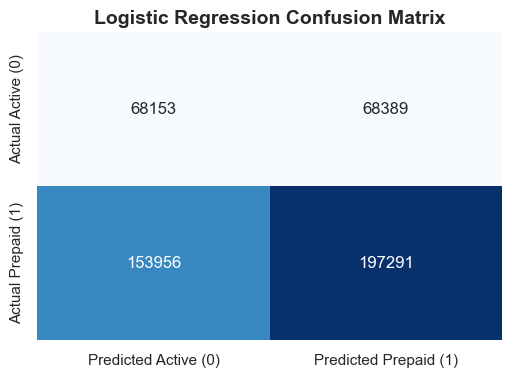

In [2]:
print("🤖 Training Baseline Logistic Regression...")
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predictions (Standard 0.50 Threshold)
y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1] 

# Metrics
roc_auc_log = roc_auc_score(y_test, y_prob_log)
precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
pr_auc_log = auc(recall_log, precision_log)

print(f"✅ Logistic Regression -> ROC-AUC: {roc_auc_log:.4f} | PR-AUC: {pr_auc_log:.4f}")

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Active (0)', 'Predicted Prepaid (1)'],
            yticklabels=['Actual Active (0)', 'Actual Prepaid (1)'])
plt.title('Logistic Regression Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()

🏆 Training Champion XGBoost (Tuned Parameters)...

🚀 FINAL OUT-OF-TIME VALIDATION SCOREBOARD (2017)
ROC-AUC  : 0.5999
PR-AUC   : 0.7753
F1-Score : 0.7408
Precision: 0.7623
Recall   : 0.7204


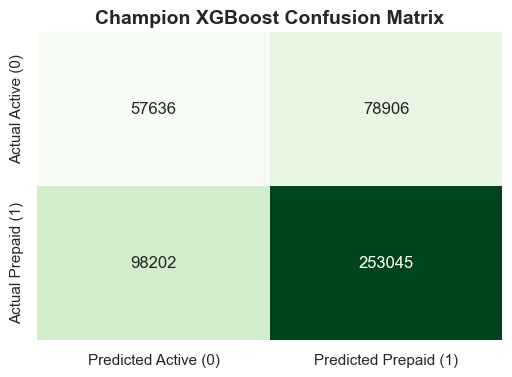

In [3]:
print("🏆 Training Champion XGBoost (Tuned Parameters)...")
champion_xgb = xgb.XGBClassifier(
    max_depth=7,
    learning_rate=0.05,
    n_estimators=500,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='auc',
    n_jobs=-1
)
champion_xgb.fit(X_train, y_train)

# Predictions (Standard 0.50 Threshold)
y_pred_xgb = champion_xgb.predict(X_test)
y_prob_xgb = champion_xgb.predict_proba(X_test)[:, 1]

# Advanced Metrics
roc_auc_xgb = roc_auc_score(y_test, y_prob_xgb)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob_xgb)
pr_auc_xgb = auc(recall_curve, precision_curve)

f1_xgb = f1_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)

print("\n" + "="*50)
print("🚀 FINAL OUT-OF-TIME VALIDATION SCOREBOARD (2017)")
print("="*50)
print(f"ROC-AUC  : {roc_auc_xgb:.4f}")
print(f"PR-AUC   : {pr_auc_xgb:.4f}")
print(f"F1-Score : {f1_xgb:.4f}")
print(f"Precision: {prec_xgb:.4f}")
print(f"Recall   : {rec_xgb:.4f}")
print("="*50)

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Predicted Active (0)', 'Predicted Prepaid (1)'],
            yticklabels=['Actual Active (0)', 'Actual Prepaid (1)'])
plt.title('Champion XGBoost Confusion Matrix', fontsize=14, fontweight='bold')
plt.show()


🏆 ULTIMATE METRICS COMPARISON
                         Model Accuracy Error Rate Precision Recall F1-Score
Logistic Regression (Baseline)   0.5442     0.4558    0.7426 0.5617   0.6396
              Champion XGBoost   0.6369     0.3631    0.7623 0.7204   0.7408



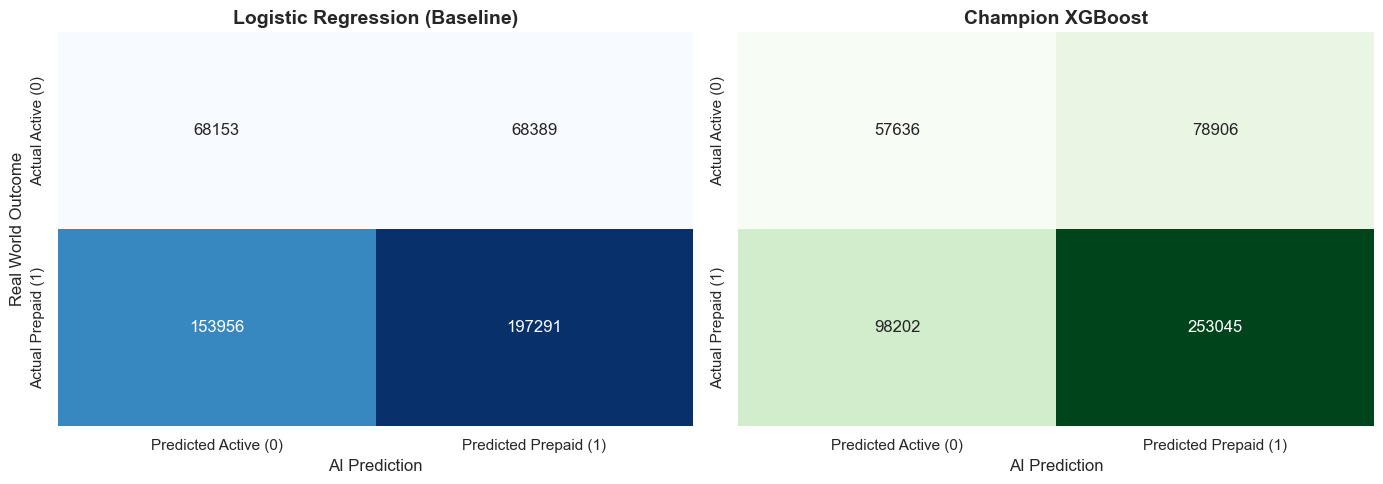

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Calculate All Metrics for Both Models
models = {
    "Logistic Regression (Baseline)": y_pred_log,
    "Champion XGBoost": y_pred_xgb
}

results = []

for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    error_rate = 1 - acc
    
    results.append({
        "Model": name,
        "Accuracy": f"{acc:.4f}",
        "Error Rate": f"{error_rate:.4f}",
        "Precision": f"{prec:.4f}",
        "Recall": f"{rec:.4f}",
        "F1-Score": f"{f1:.4f}"
    })

# Convert to DataFrame for a beautiful printout
df_results = pd.DataFrame(results)
print("\n" + "="*80)
print("🏆 ULTIMATE METRICS COMPARISON")
print("="*80)
print(df_results.to_string(index=False))
print("="*80 + "\n")

# 2. Plot Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Logistic Regression Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['Predicted Active (0)', 'Predicted Prepaid (1)'],
            yticklabels=['Actual Active (0)', 'Actual Prepaid (1)'])
axes[0].set_title('Logistic Regression (Baseline)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('AI Prediction')
axes[0].set_ylabel('Real World Outcome')

# XGBoost Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['Predicted Active (0)', 'Predicted Prepaid (1)'],
            yticklabels=['Actual Active (0)', 'Actual Prepaid (1)'])
axes[1].set_title('Champion XGBoost', fontsize=14, fontweight='bold')
axes[1].set_xlabel('AI Prediction')
axes[1].set_ylabel('') # Hide y-label for the second plot to keep it clean

plt.tight_layout()
plt.show()

🧠 Generating XGBoost Native Feature Importance...


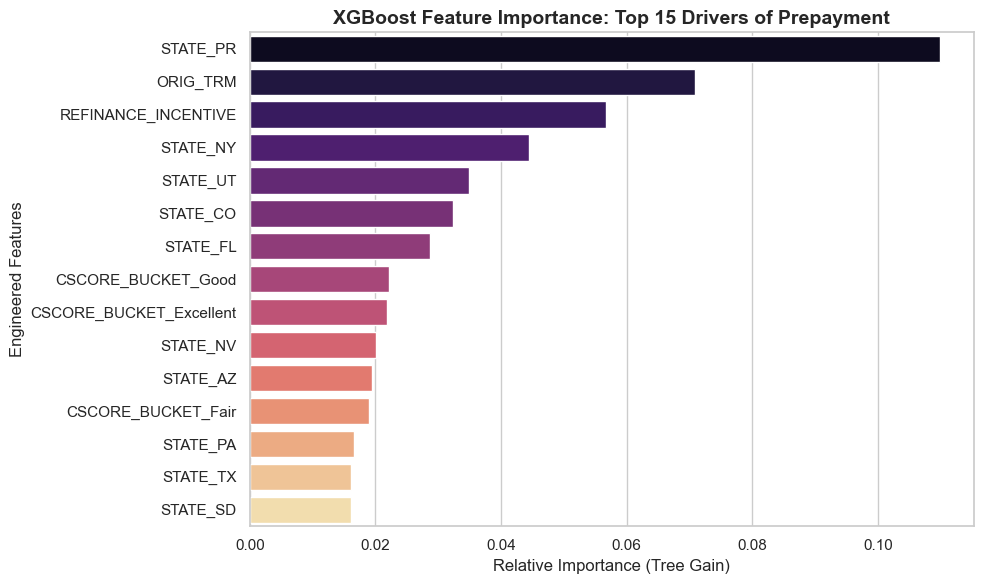

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("🧠 Generating XGBoost Native Feature Importance...")

# Extract importances from the model and map them to the column names
importances = champion_xgb.feature_importances_
feature_names = X_test.columns

# Create a clean DataFrame
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort by importance and grab the Top 15 for a clean visual
df_top15 = df_importance.sort_values(by='Importance', ascending=False).head(15)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_top15, 
    legend=False,
    hue="Feature",
    palette='magma' # Using a strong color gradient for the presentation
)

plt.title('XGBoost Feature Importance: Top 15 Drivers of Prepayment', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Tree Gain)', fontsize=12)
plt.ylabel('Engineered Features', fontsize=12)
plt.tight_layout()
plt.show()

🏟️  MULTI-MODEL SHOWDOWN: Training All Contenders...

🌲 Training Random Forest...
   ✅ Random Forest trained.
🚀 Training AdaBoost...
   ✅ AdaBoost trained.
📈 Training Gradient Boosting (sklearn)...
   ✅ Gradient Boosting trained.
⚡ Training LightGBM...
   ✅ LightGBM trained.

✅ ALL MODELS TRAINED SUCCESSFULLY

🏆 MULTI-MODEL PERFORMANCE COMPARISON (Out-of-Time: 2017)
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  PR-AUC
      Random Forest    0.6961     0.7426  0.8847    0.8074   0.6069  0.7818
  Gradient Boosting    0.6614     0.7565  0.7811    0.7686   0.6048  0.7788
           LightGBM    0.6386     0.7622  0.7239    0.7426   0.6003  0.7754
      XGBoost Model    0.6369     0.7623  0.7204    0.7408   0.5999  0.7753
           AdaBoost    0.2926     0.7674  0.0252    0.0489   0.5027  0.7472
Logistic Regression    0.5442     0.7426  0.5617    0.6396   0.5349  0.7370


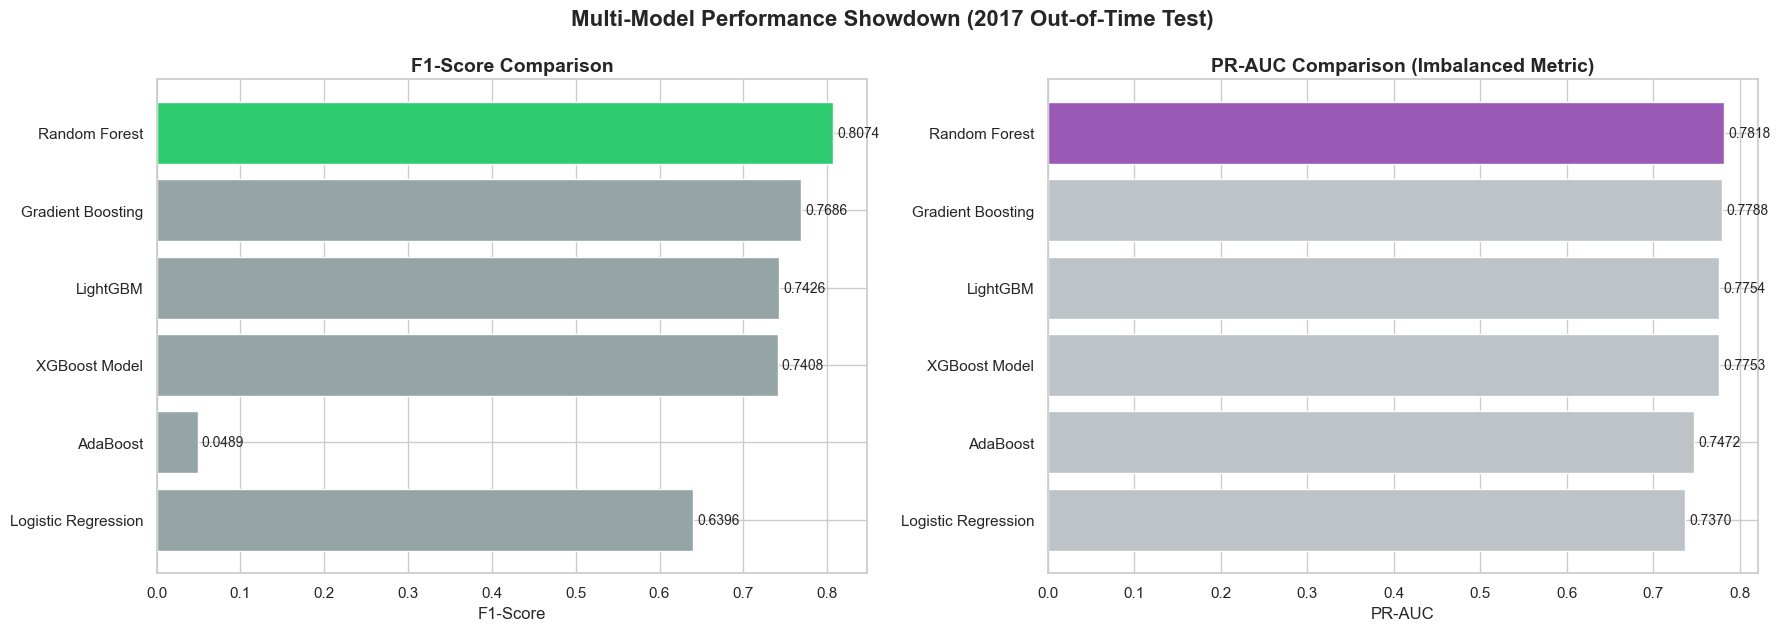

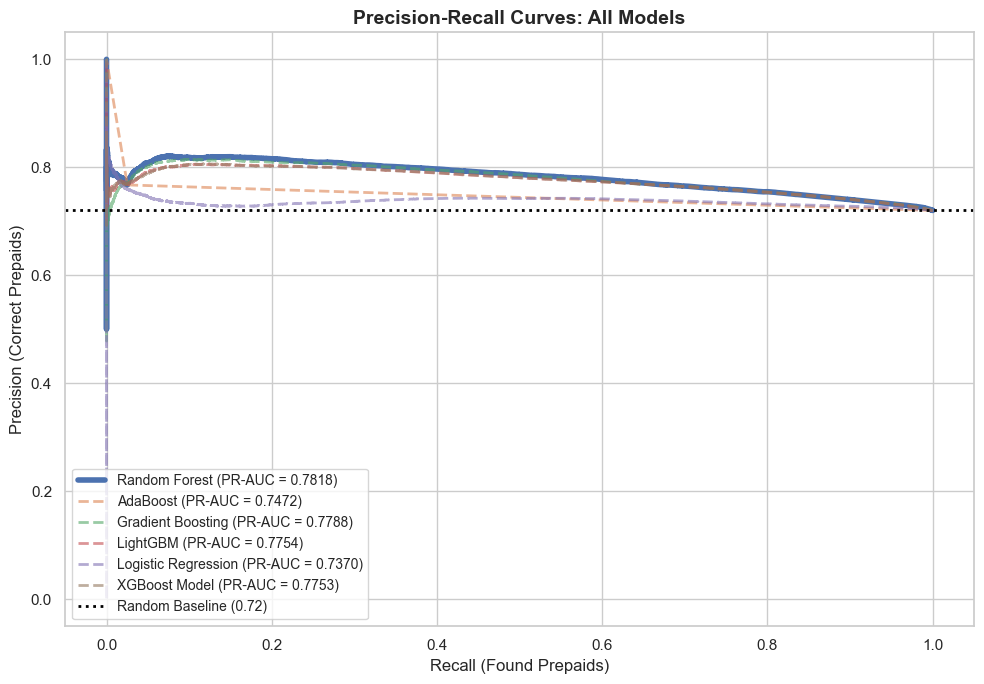


✅ Multi-model comparison complete.


In [8]:
import warnings
warnings.filterwarnings('ignore') # 🛑 This suppresses all annoying deprecation warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import (
    RandomForestClassifier, 
    AdaBoostClassifier, 
    GradientBoostingClassifier
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix
)

# Try to import LightGBM — if not installed, skip it
try:
    import lightgbm as lgb
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print("⚠️ LightGBM not installed. Skipping LightGBM model.")

# ------------------------------------------------------------------
# 1. Define & Train All Contender Models
# ------------------------------------------------------------------
print("="*70)
print("🏟️  MULTI-MODEL SHOWDOWN: Training All Contenders...")
print("="*70)

# --- Random Forest ---
print("\n🌲 Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print("   ✅ Random Forest trained.")

# --- AdaBoost ---
print("🚀 Training AdaBoost...")
ada_model = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    algorithm='SAMME'
)
ada_model.fit(X_train, y_train)
y_pred_ada = ada_model.predict(X_test)
y_prob_ada = ada_model.predict_proba(X_test)[:, 1]
print("   ✅ AdaBoost trained.")

# --- Gradient Boosting (sklearn) ---
print("📈 Training Gradient Boosting (sklearn)...")
gb_model = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]
print("   ✅ Gradient Boosting trained.")

# --- LightGBM (if available) ---
if HAS_LGBM:
    print("⚡ Training LightGBM...")
    lgbm_model = lgb.LGBMClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=1.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
    lgbm_model.fit(X_train, y_train)
    y_pred_lgbm = lgbm_model.predict(X_test)
    y_prob_lgbm = lgbm_model.predict_proba(X_test)[:, 1]
    print("   ✅ LightGBM trained.")

print("\n" + "="*70)
print("✅ ALL MODELS TRAINED SUCCESSFULLY")
print("="*70)

# ------------------------------------------------------------------
# 2. Build Comprehensive Metrics Table
# ------------------------------------------------------------------
# Safely pull in Logistic and XGBoost if they exist in memory
all_models = {
    "Random Forest": (y_pred_rf, y_prob_rf),
    "AdaBoost": (y_pred_ada, y_prob_ada),
    "Gradient Boosting": (y_pred_gb, y_prob_gb),
}

if HAS_LGBM:
    all_models["LightGBM"] = (y_pred_lgbm, y_prob_lgbm)

try:
    all_models["Logistic Regression"] = (y_pred_log, y_prob_log)
    all_models["XGBoost Model"] = (y_pred_xgb, y_prob_xgb)
except NameError:
    print("⚠️  Warning: Ensure Logistic Regression and XGBoost were run in previous cells.")

results = []
for name, (preds, probs) in all_models.items():
    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    roc = roc_auc_score(y_test, probs)
    pr_precision, pr_recall, _ = precision_recall_curve(y_test, probs)
    pr_auc_val = auc(pr_recall, pr_precision)
    
    results.append({
        "Model": name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc, 4),
        "PR-AUC": round(pr_auc_val, 4)
    })

df_comparison = pd.DataFrame(results)
df_comparison = df_comparison.sort_values(by="PR-AUC", ascending=False)

print("\n" + "="*80)
print("🏆 MULTI-MODEL PERFORMANCE COMPARISON (Out-of-Time: 2017)")
print("="*80)
print(df_comparison.to_string(index=False))
print("="*80)

# ------------------------------------------------------------------
# 3. Visualization: Bar Chart Comparison
# ------------------------------------------------------------------
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Highlight Random Forest since it is the winner
winner_name = 'Random Forest'

# Chart 1: F1-Score Comparison 
ax1 = axes[0]
colors_f1 = ['#2ecc71' if m == winner_name else '#95a5a6' for m in df_comparison['Model']]
ax1.barh(df_comparison['Model'], df_comparison['F1-Score'], color=colors_f1)
ax1.set_xlabel('F1-Score', fontsize=12)
ax1.set_title('F1-Score Comparison', fontsize=14, fontweight='bold')
ax1.invert_yaxis() 
for i, v in enumerate(df_comparison['F1-Score']):
    ax1.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

# Chart 2: PR-AUC Comparison
ax2 = axes[1]
colors_pr = ['#9b59b6' if m == winner_name else '#bdc3c7' for m in df_comparison['Model']]
ax2.barh(df_comparison['Model'], df_comparison['PR-AUC'], color=colors_pr)
ax2.set_xlabel('PR-AUC', fontsize=12)
ax2.set_title('PR-AUC Comparison (Imbalanced Metric)', fontsize=14, fontweight='bold')
ax2.invert_yaxis()
for i, v in enumerate(df_comparison['PR-AUC']):
    ax2.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Multi-Model Performance Showdown (2017 Out-of-Time Test)', fontsize=16, fontweight='bold', y=1.05)
plt.show()

# ------------------------------------------------------------------
# 4. Overlay PR Curves for All Models
# ------------------------------------------------------------------
plt.figure(figsize=(10, 7))
baseline_pr = sum(y_test) / len(y_test)

for name, (preds, probs) in all_models.items():
    pr_p, pr_r, _ = precision_recall_curve(y_test, probs)
    pr_a = auc(pr_r, pr_p)
    
    lw = 4 if name == winner_name else 2
    ls = '-' if name == winner_name else '--'
    alpha = 1.0 if name == winner_name else 0.6
    
    plt.plot(pr_r, pr_p, lw=lw, linestyle=ls, alpha=alpha, label=f'{name} (PR-AUC = {pr_a:.4f})')

plt.axhline(y=baseline_pr, color='black', lw=2, linestyle=':', label=f'Random Baseline ({baseline_pr:.2f})')
plt.xlabel('Recall (Found Prepaids)', fontsize=12)
plt.ylabel('Precision (Correct Prepaids)', fontsize=12)
plt.title('Precision-Recall Curves: All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=10)
plt.tight_layout()
plt.show()
print("\n✅ Multi-model comparison complete.")

📊 Generating XGBoost vs. Random Forest Showdown...


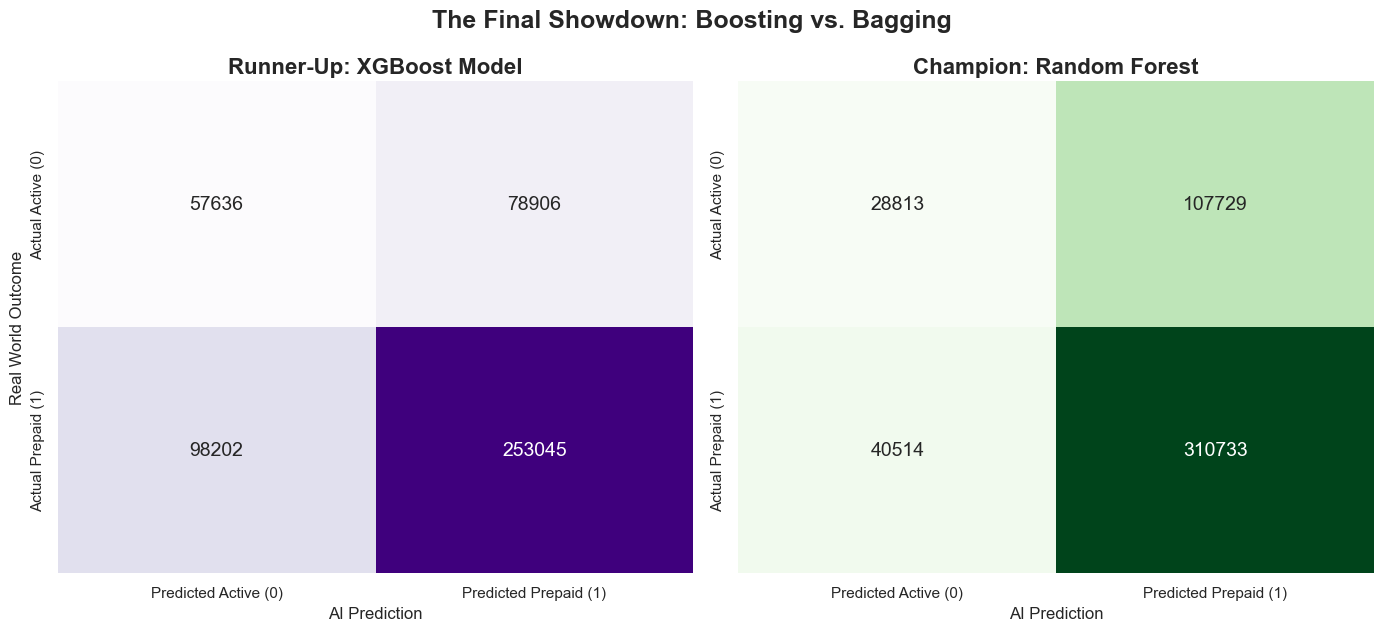

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("📊 Generating XGBoost vs. Random Forest Showdown...")

# Generate matrices (Ensure y_pred_xgb and y_pred_rf are in memory)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Matrix 1: XGBoost (Runner-Up)
# Using a 'Purples' color map to distinguish it from the final Champion
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Purples', cbar=False, ax=axes[0],
            annot_kws={"size": 14}, # Larger text for presentations
            xticklabels=['Predicted Active (0)', 'Predicted Prepaid (1)'],
            yticklabels=['Actual Active (0)', 'Actual Prepaid (1)'])
axes[0].set_title('Runner-Up: XGBoost Model', fontsize=16, fontweight='bold')
axes[0].set_xlabel('AI Prediction', fontsize=12)
axes[0].set_ylabel('Real World Outcome', fontsize=12)

# Matrix 2: Random Forest (Champion)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', cbar=False, ax=axes[1],
            annot_kws={"size": 14},
            xticklabels=['Predicted Active (0)', 'Predicted Prepaid (1)'],
            yticklabels=['Actual Active (0)', 'Actual Prepaid (1)'])
axes[1].set_title('Champion: Random Forest', fontsize=16, fontweight='bold')
axes[1].set_xlabel('AI Prediction', fontsize=12)
axes[1].set_ylabel('') # Hide y-label on the right to keep it clean

plt.tight_layout()
plt.suptitle('The Final Showdown: Boosting vs. Bagging', fontsize=18, fontweight='bold', y=1.05)
plt.show()